In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import seaborn as sns
import os
from torchinfo import summary

from tqdm import tqdm

sns.set_style("whitegrid")

# Для Jupyter
%matplotlib inline

# --- Device (исправлено) ---
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps


## 0. Data preparation

In [2]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(
    root='../../data',
    train=True,
    download=True,
    transform=transform_train
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,  # оптимально для MPS
    shuffle=True,
    num_workers=0  # важно для Mac
)

testset = torchvision.datasets.CIFAR10(
    root='../../data',
    train=False,
    download=True,
    transform=transform_test
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

## 1. Custom Convolutional model

In [3]:
class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.shape[0], -1)

In [4]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3)
        self.conv2 = nn.Conv2d(64, 10, 3)
        self.dense = nn.Linear(10 * 28 * 28, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.flatten(1)
        x = self.dense(x)
        return x


model = Model()

In [5]:
import torchsummary

In [6]:
torchsummary.summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 30, 30]           1,792
            Conv2d-2           [-1, 10, 28, 28]           5,770
            Linear-3                   [-1, 10]          78,410
Total params: 85,972
Trainable params: 85,972
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.50
Params size (MB): 0.33
Estimated Total Size (MB): 0.84
----------------------------------------------------------------


## 2. Write train and test function

In [7]:
def train(model, optim, criterion, dataloader, epoch, device):
    total = 0
    correct = 0
    train_loss = 0

    model.train()
    for data, label in dataloader:
        data = data.to(device)
        label = label.to(device)

        optim.zero_grad()

        output = model(data)
        loss = criterion(output, label)

        loss.backward()
        optim.step()

        train_loss += loss.item() * data.size(0)

        pred = output.argmax(1)
        total += data.size(0)
        correct += pred.eq(label).sum().item()

    return train_loss / total, 100. * correct / total

In [8]:
def test(model, criterion, dataloader, epoch, device, best_acc, model_name='model'):
    total = 0
    correct = 0
    test_loss = 0

    model.eval()
    with torch.no_grad():
        for data, label in dataloader:
            data = data.to(device)
            label = label.to(device)

            output = model(data)
            loss = criterion(output, label)

            test_loss += loss.item() * data.size(0)

            pred = output.argmax(1)
            correct += pred.eq(label).sum().item()
            total += data.size(0)

    acc = 100. * correct / total

    if acc > best_acc:
        state = {
            'net': model.state_dict(),
            'acc': acc,
            'epoch': epoch,
        }
        if not os.path.isdir('checkpoint'):
            os.mkdir('checkpoint')
        torch.save(state, f'./checkpoint/ckpt_{model_name}.pth')

    return test_loss / total, acc

## 3. Train Model

In [9]:
from IPython.display import clear_output
import numpy as np

In [10]:
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),
                      lr=0.001, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, 2, gamma=0.5)

In [11]:
train_losses = []
test_losses = []
best_acc = 0
best_epoch = -1

for i in range(10):
    train_loss, train_acc = train(model, optimizer, criterion, trainloader, i, device)
    test_loss, test_acc = test(model, criterion, testloader, i, device, best_acc)

    scheduler.step()   # ← исправлено

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if test_acc > best_acc:
        best_acc = test_acc
        best_epoch = i

    print(f"Epoch {i}: "
          f"Train Loss={train_loss:.4f}, Acc={train_acc:.2f} | "
          f"Test Loss={test_loss:.4f}, Acc={test_acc:.2f}")

Epoch 0: Train Loss=1.8070, Acc=34.80 | Test Loss=1.4968, Acc=45.86
Epoch 1: Train Loss=1.5518, Acc=43.82 | Test Loss=1.3912, Acc=50.38
Epoch 2: Train Loss=1.4596, Acc=47.46 | Test Loss=1.3482, Acc=51.30
Epoch 3: Train Loss=1.4304, Acc=48.38 | Test Loss=1.3431, Acc=51.50
Epoch 4: Train Loss=1.3934, Acc=50.26 | Test Loss=1.2901, Acc=53.87
Epoch 5: Train Loss=1.3811, Acc=50.56 | Test Loss=1.2746, Acc=54.39
Epoch 6: Train Loss=1.3677, Acc=51.09 | Test Loss=1.2523, Acc=55.27
Epoch 7: Train Loss=1.3561, Acc=51.41 | Test Loss=1.2441, Acc=55.47
Epoch 8: Train Loss=1.3498, Acc=51.90 | Test Loss=1.2437, Acc=55.91
Epoch 9: Train Loss=1.3450, Acc=51.87 | Test Loss=1.2348, Acc=56.19


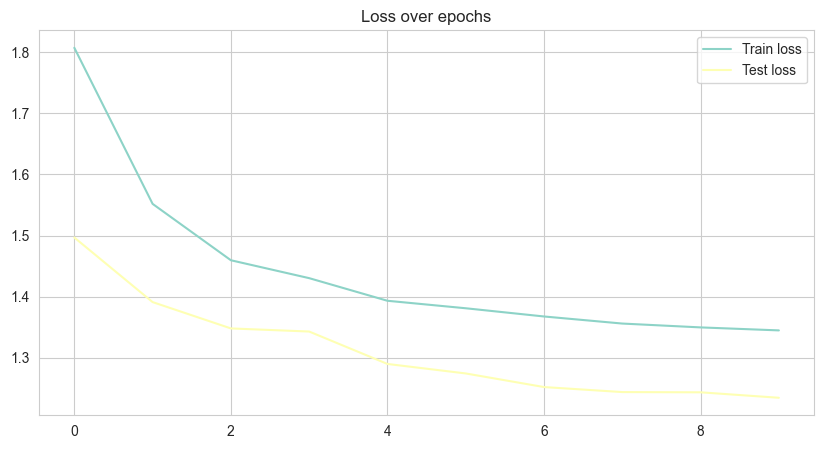

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(test_losses, label="Test loss")
plt.legend()
plt.title("Loss over epochs")
plt.show()

In [13]:
best_acc

56.19

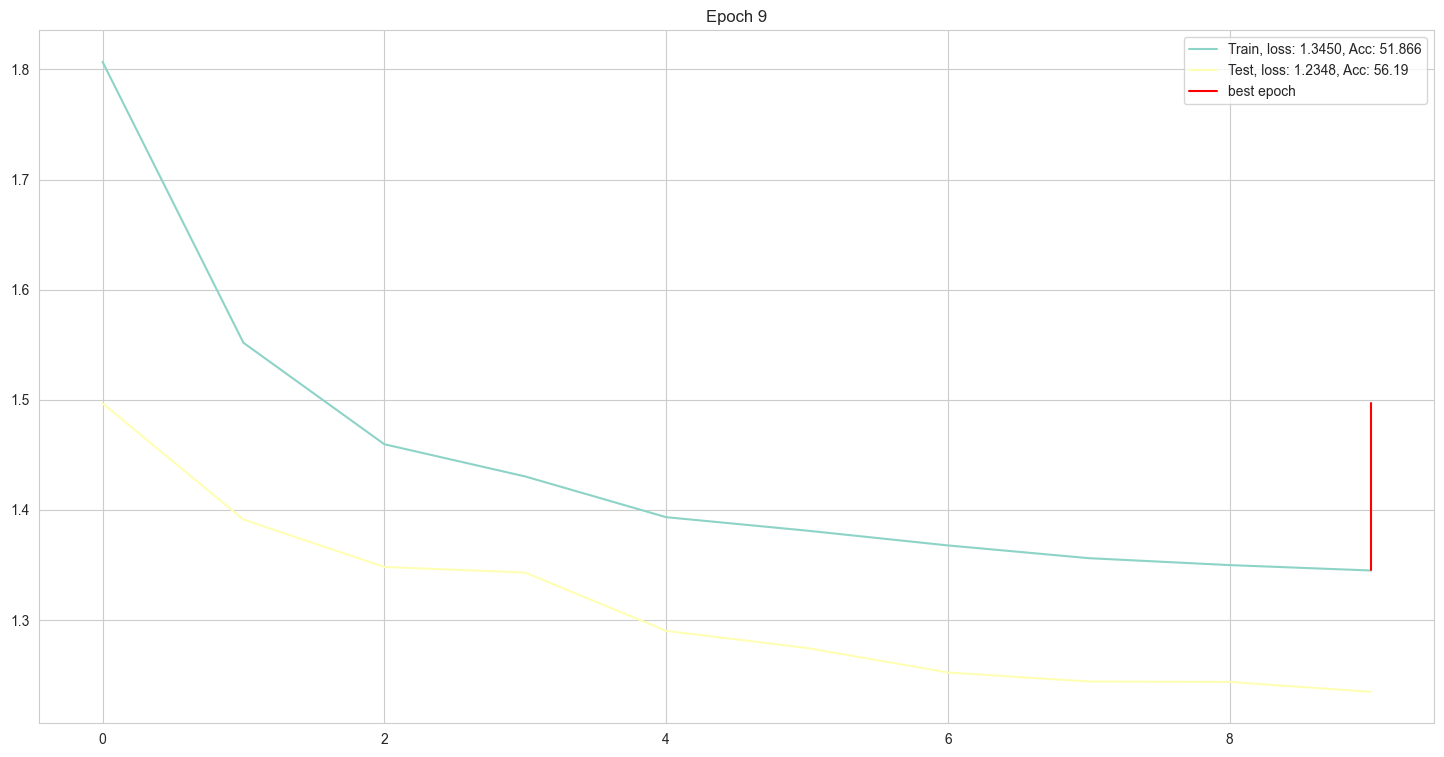

In [14]:
plt.figure(figsize=(18, 9))
plt.plot(np.arange(len(train_losses)), train_losses, label=f'Train, loss: {train_loss:.4f}, Acc: {train_acc}')
plt.plot(np.arange(len(test_losses)), test_losses, label=f'Test, loss: {test_loss:.4f}, Acc: {test_acc}')
plt.plot(np.ones(10) * best_epoch, np.linspace(np.min(train_losses).item(), np.max(test_losses).item(), 10), color='r',
         label='best epoch')
plt.title(f'Epoch {i}')
plt.legend(loc='best')

### BatchNorm

https://arxiv.org/abs/1502.03167

![](https://standardfrancis.files.wordpress.com/2015/04/screenshot-from-2015-04-16-133436.png)

In [15]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 10, 3)
        self.bn2 = nn.BatchNorm2d(10)
        self.dense = nn.Linear(10 * 28 * 28, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.flatten(1)
        x = self.dense(x)
        return x


model = Model()

In [16]:
summary(model, (1, 3, 32, 32), device="mps")

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 30, 30]           1,792
├─BatchNorm2d: 1-2                       [1, 64, 30, 30]           128
├─Conv2d: 1-3                            [1, 10, 28, 28]           5,770
├─BatchNorm2d: 1-4                       [1, 10, 28, 28]           20
├─Linear: 1-5                            [1, 10]                   78,410
Total params: 86,120
Trainable params: 86,120
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 6.22
Input size (MB): 0.01
Forward/backward pass size (MB): 1.05
Params size (MB): 0.34
Estimated Total Size (MB): 1.40

In [17]:
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),
                      lr=0.001, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, 2, gamma=0.5)

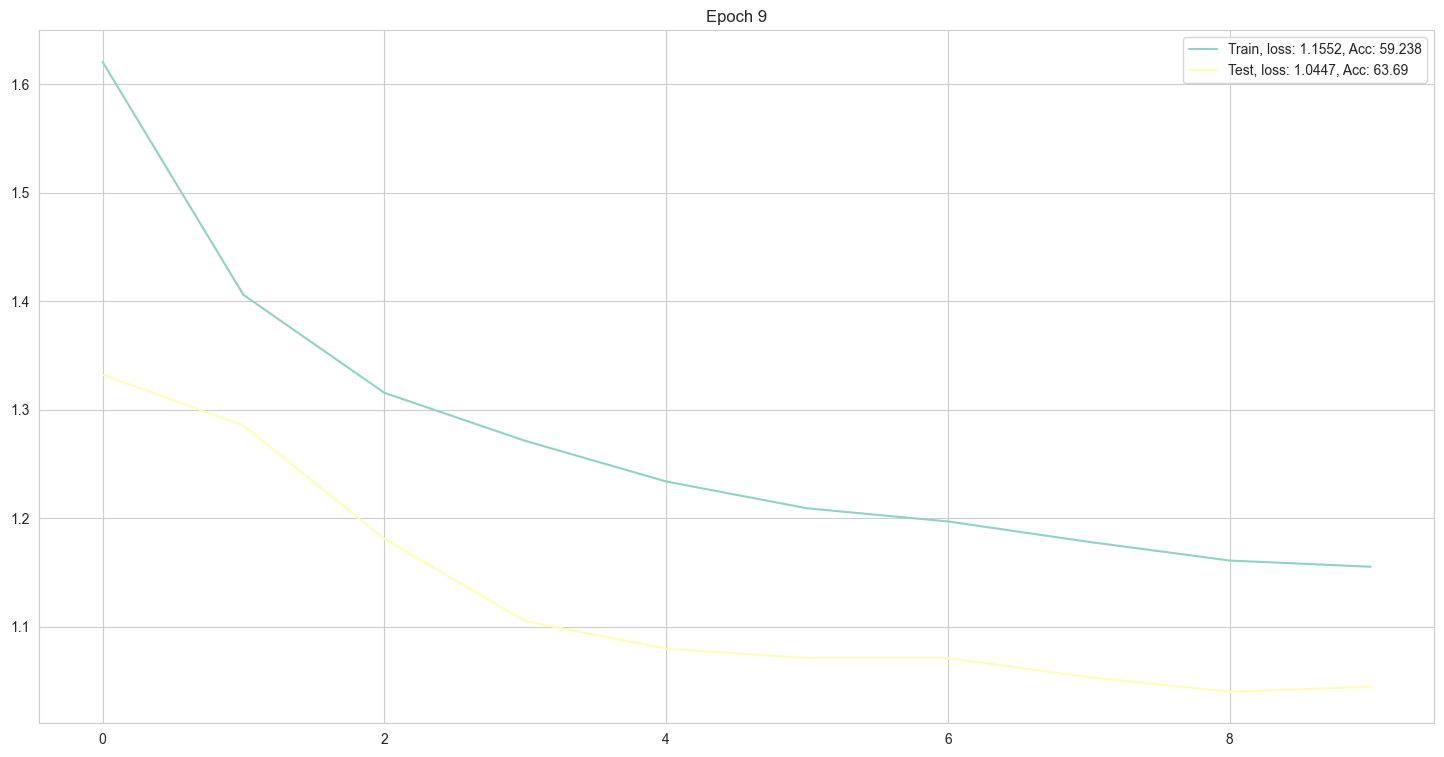

In [18]:
train_losses = []
test_losses = []
best_acc = 0
best_epoch = -1
for i in range(10):
    train_loss, train_acc = train(model, optimizer, criterion, trainloader, i, device)
    train_losses.append(train_loss)
    test_loss, test_acc = test(model, criterion, testloader, i, device, best_acc, 'with_bn')
    scheduler.step(test_loss)
    test_losses.append(test_loss)
    best_acc = max(best_acc, test_acc)
    best_epoch = i if best_acc == test_acc else best_epoch
    clear_output()
    plt.figure(figsize=(18, 9))
    plt.plot(np.arange(len(train_losses)), train_losses, label=f'Train, loss: {train_loss:.4f}, Acc: {train_acc}')
    plt.plot(np.arange(len(test_losses)), test_losses, label=f'Test, loss: {test_loss:.4f}, Acc: {test_acc}')
    plt.title(f'Epoch {i}')
    plt.legend(loc='best')
    plt.show()

In [19]:
best_acc

63.69

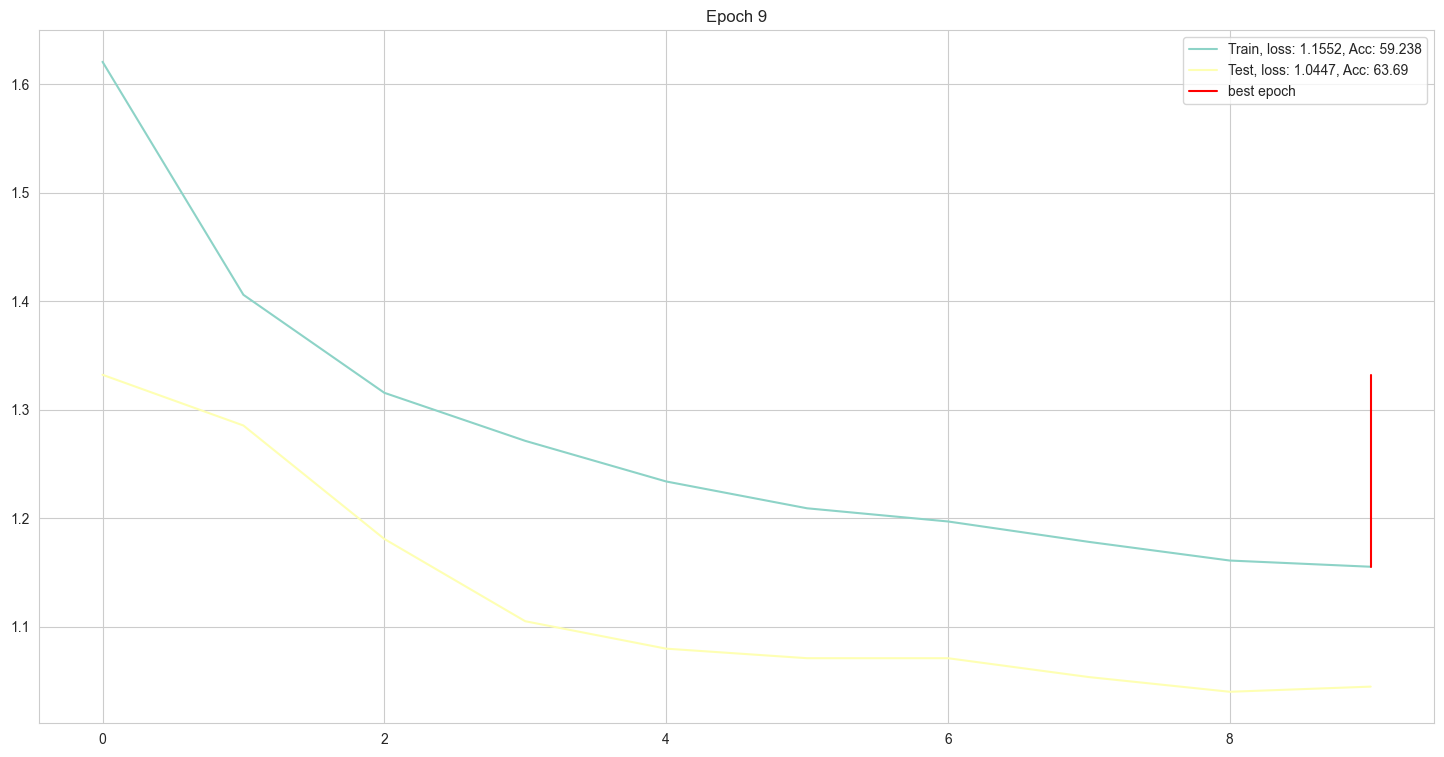

In [20]:
plt.figure(figsize=(18, 9))
plt.plot(np.arange(len(train_losses)), train_losses, label=f'Train, loss: {train_loss:.4f}, Acc: {train_acc}')
plt.plot(np.arange(len(test_losses)), test_losses, label=f'Test, loss: {test_loss:.4f}, Acc: {test_acc}')
plt.plot(np.ones(10) * best_epoch, np.linspace(np.min(train_losses).item(), np.max(test_losses).item(), 10), color='r',
         label='best epoch')
plt.title(f'Epoch {i}')
plt.legend(loc='best')

## 4. Add some augmentations

https://pytorch.org/docs/stable/torchvision/transforms.html

We will add some basic augmentations

In [21]:
transform_train = transforms.Compose([
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(25),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:24<00:00, 6.90MB/s] 


In [22]:
model = nn.Sequential()

# dense "head"
model.add_module('conv1', nn.Conv2d(3, 64, 3))
model.add_module('bn1', nn.BatchNorm2d(64))
model.add_module('conv1_relu', nn.ReLU())
model.add_module('conv2', nn.Conv2d(64, 10, 3))
model.add_module('bn2', nn.BatchNorm2d(10))
model.add_module('conv2_relu', nn.ReLU())

model.add_module('flat', Flatten())
model.add_module('dense', nn.Linear(10 * 28 * 28, 10))

In [23]:
def train(model, optim, criterion, dataloader, epoch, device, add_noise=True):
    total = 0
    correct = 0
    train_loss = 0

    model.train()
    for data, label in dataloader:
        data, label = data.to(device), label.to(device)
        
        # Add noise on device (faster)
        if add_noise:
            data = data + torch.empty_like(data).normal_(0, 0.0001)
        
        optim.zero_grad()
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        optim.step()

        train_loss += loss.item()
        pred = output.argmax(1)
        total += output.shape[0]
        correct += pred.eq(label).sum().item()
    return train_loss / total, 100. * correct / total

In [24]:
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),
                      lr=0.001, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, 2, gamma=0.5)

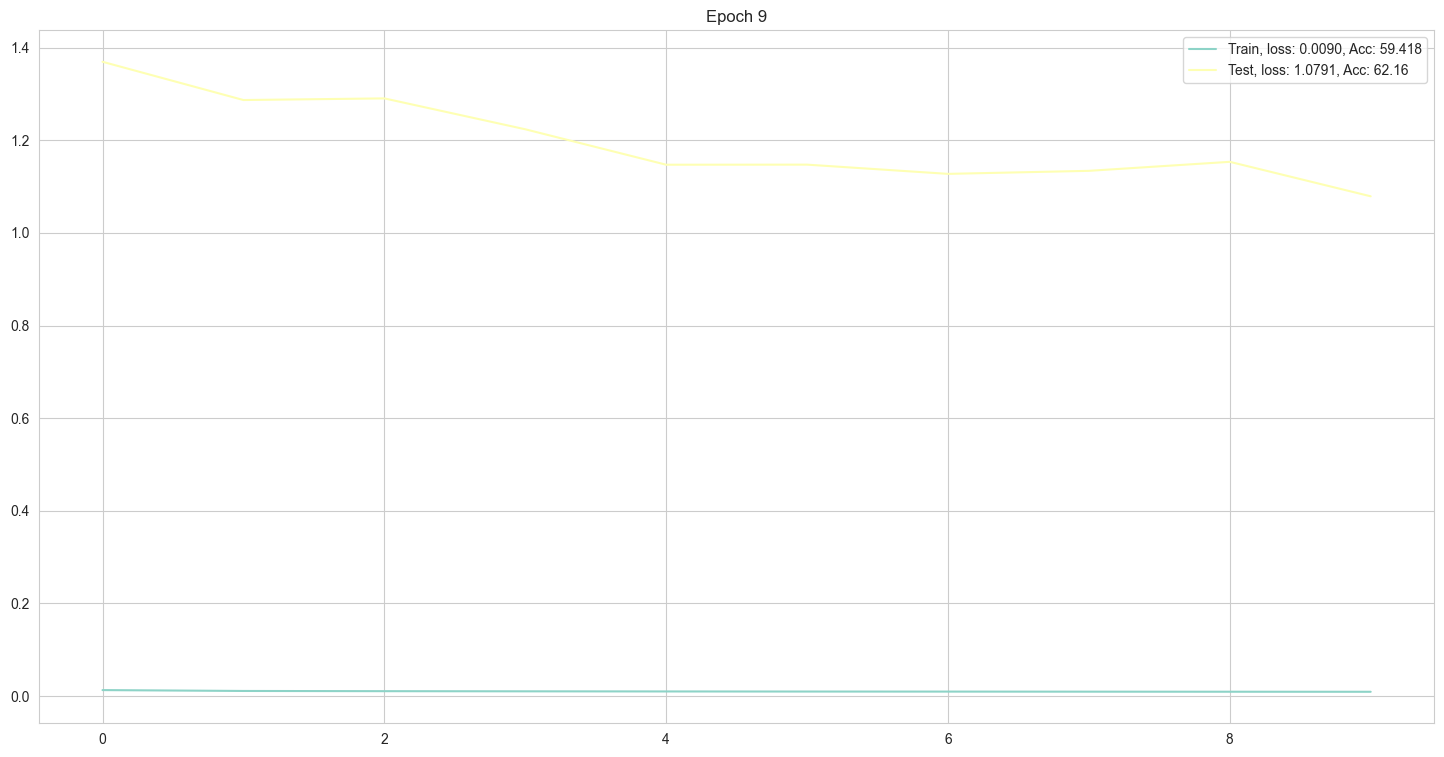

In [25]:
train_losses = []
test_losses = []
best_acc = 0
best_epoch = -1
for i in range(10):
    train_loss, train_acc = train(model, optimizer, criterion, trainloader, i, device)
    train_losses.append(train_loss)
    test_loss, test_acc = test(model, criterion, testloader, i, device, best_acc, 'bn_and_aug')
    scheduler.step(test_loss)
    test_losses.append(test_loss)
    best_acc = max(best_acc, test_acc)
    best_epoch = i if best_acc == test_acc else best_epoch
    clear_output()
    plt.figure(figsize=(18, 9))
    plt.plot(np.arange(len(train_losses)), train_losses, label=f'Train, loss: {train_loss:.4f}, Acc: {train_acc}')
    plt.plot(np.arange(len(test_losses)), test_losses, label=f'Test, loss: {test_loss:.4f}, Acc: {test_acc}')
    plt.title(f'Epoch {i}')
    plt.legend(loc='best')
    plt.show()

# 5. Transfer Learning

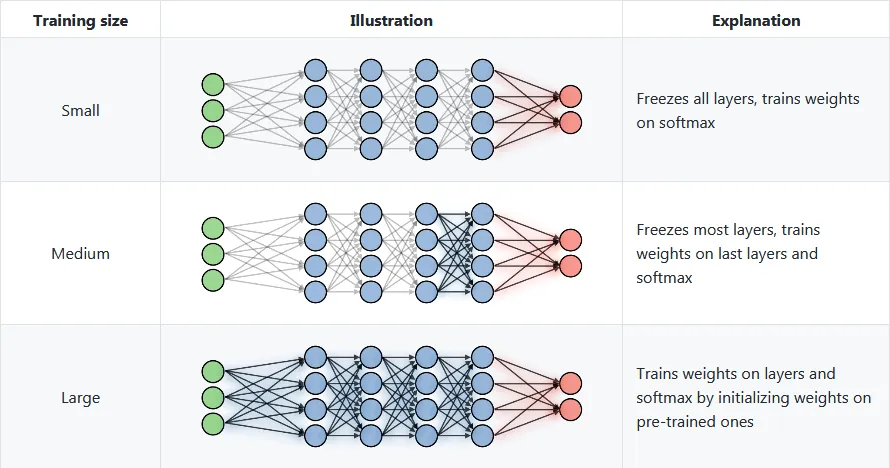

### Types of Fine-Tuning

##### 1. Fine-tuning all layers

**Description:**
All the weights of the trained model become available for modification during training on the new dataset.

**Advantages:**
- Can achieve the best results if the new dataset is sufficiently large or significantly different from the original.
- The model is fully adapted to your task.

**Disadvantages:**
- Requires more computational resources.
- There is a risk of overfitting on small datasets.
- It is necessary to carefully select the learning speed and other parameters.


##### 2. Additional training of only the "head" (i.e., only the last layer, usually the classifier)

**Description:**
All "body" weights (feature extractor) are frozen. Only the parameters of the last layer (head, classifier) are changed, usually this is the softmax/linear layer.

**Advantages:**
- Fast, efficient in terms of resources.
- It works especially well when your task is very similar to the original one (i.e., the signs are already well learned).
- Minimal risk of overfitting.

**Disadvantages:**
- If the new task is very different, such an approach is limited - there may not be enough adaptability.
- The quality level is limited by the capabilities of the initial characteristics.



##### 3. Only completing the last few layers

**Description:**
The model is partially "frozen": the first layers (usually involving basic features, such as lines, colors, and textures) are fixed, and the last layers are updated during training.

**Advantages:**
- Balances speed and adaptability.
- Allows you to "re-train" the most specific layers for your task without destroying the basic "universal" characteristics.

**Disadvantages:**
- Finding the optimal amount of "melting" layers requires experiments.
- For small datasets, the risk of overtraining is higher than for the head-only option.
- If the task is very similar to the original one, it doesn't always bring significant winnings.

In [26]:
def change_head_of_resnet18(model, NUM_CLASSES):
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model

In [ ]:
from torchvision import models

In [27]:
model_with_ft_head = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

NameError: name 'models' is not defined

### Only the head

In [ ]:
for param in model_with_ft_head.parameters():
    param.requires_grad = False

model_with_ft_head = change_head_of_resnet18(model_with_ft_head, 10)
model_head = model_with_ft_head.to(device)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),
                      lr=0.001, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, 2, gamma=0.5)

train_losses = []
test_losses = []
best_acc = 0
best_epoch = -1
for i in range(10):
    train_loss, train_acc = train(model, optimizer, criterion, trainloader, i, device)
    train_losses.append(train_loss)
    test_loss, test_acc = test(model, criterion, testloader, i, device, best_acc, 'bn_and_aug')
    scheduler.step(test_loss)
    test_losses.append(test_loss)
    best_acc = max(best_acc, test_acc)
    best_epoch = i if best_acc == test_acc else best_epoch
    clear_output()
    plt.figure(figsize=(18, 9))
    plt.plot(np.arange(len(train_losses)), train_losses, label=f'Train, loss: {train_loss:.4f}, Acc: {train_acc}')
    plt.plot(np.arange(len(test_losses)), test_losses, label=f'Test, loss: {test_loss:.4f}, Acc: {test_acc}')
    plt.title(f'Epoch {i}')
    plt.legend(loc='best')
    plt.show()

### Finetune All

In [ ]:
model_finetune_all = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

model_finetune_all = change_head_of_resnet18(model_finetune_all, NUM_CLASSES)
model_finetune_all = model_finetune_all.to(device)

for param in model_finetune_all.parameters():
    param.requires_grad = True

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),
                      lr=0.001, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, 2, gamma=0.5)

train_losses = []
test_losses = []
best_acc = 0
best_epoch = -1
for i in range(10):
    train_loss, train_acc = train(model, optimizer, criterion, trainloader, i, device)
    train_losses.append(train_loss)
    test_loss, test_acc = test(model, criterion, testloader, i, device, best_acc, 'bn_and_aug')
    scheduler.step(test_loss)
    test_losses.append(test_loss)
    best_acc = max(best_acc, test_acc)
    best_epoch = i if best_acc == test_acc else best_epoch
    clear_output()
    plt.figure(figsize=(18, 9))
    plt.plot(np.arange(len(train_losses)), train_losses, label=f'Train, loss: {train_loss:.4f}, Acc: {train_acc}')
    plt.plot(np.arange(len(test_losses)), test_losses, label=f'Test, loss: {test_loss:.4f}, Acc: {test_acc}')
    plt.title(f'Epoch {i}')
    plt.legend(loc='best')
    plt.show()